In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

url = "http://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"

columns = [
    "status", "duration", "credit_history", "purpose", "credit_amount",
    "savings", "employment", "installment_rate", "personal_status",
    "other_debtors", "residence_since", "property", "age",
    "other_installment_plans", "housing", "existing_credits",
    "job", "people_liable", "telephone", "foreign_worker", "target"
]

df = pd.read_csv(url, sep=" ", header=None, names=columns)

print(df.head())
print(df.shape)
# 1 = good → 0
# 2 = bad → 1

df["target"] = df["target"].map({1: 0, 2: 1})

df["target"].value_counts()
df_encoded = pd.get_dummies(df, drop_first=True)

print(df_encoded.shape)
X = df_encoded.drop(columns=["target"])
y = df_encoded["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)
y_prob = log_model.predict_proba(X_test)[:, 1]

print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred))

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("=== Random Forest ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print(classification_report(y_test, y_pred_rf))

importance = rf_model.feature_importances_

feature_importance = pd.Series(importance, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)

print(feature_importance.head(10))

  status  duration credit_history purpose  credit_amount savings employment  \
0    A11         6            A34     A43           1169     A65        A75   
1    A12        48            A32     A43           5951     A61        A73   
2    A14        12            A34     A46           2096     A61        A74   
3    A11        42            A32     A42           7882     A61        A74   
4    A11        24            A33     A40           4870     A61        A73   

   installment_rate personal_status other_debtors  ...  property age  \
0                 4             A93          A101  ...      A121  67   
1                 2             A92          A101  ...      A121  22   
2                 2             A93          A101  ...      A121  49   
3                 2             A93          A103  ...      A122  45   
4                 3             A93          A101  ...      A124  53   

   other_installment_plans housing existing_credits   job people_liable  \
0                

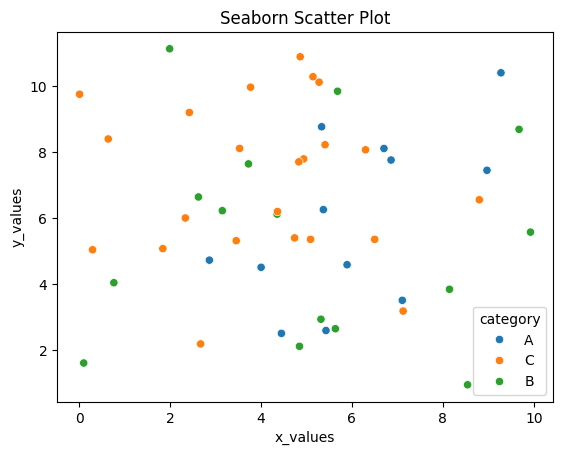

In [12]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# DataFrame
data = {
    'x_values': np.random.rand(50) * 10,
    'y_values': np.random.rand(50) * 10 + np.random.rand(50) * 2,
    'category': np.random.choice(['A', 'B', 'C'], 50)
}
df_plot = pd.DataFrame(data)

# Scatterplot
sns.scatterplot(x='x_values', y='y_values', hue='category', data=df_plot)
plt.title("Seaborn Scatter Plot")
plt.show()

# Task
`df` is loaded and `target` has been mapped from `(1, 2)` to `(0, 1)`. Let's visualize the target variable's distribution to check for class imbalance, and then visualize the distributions of `credit_amount`, `age`, and `duration` as per the plan.

## Analyze Target Imbalance

### Subtask:
Visualize the distribution of the target variable (`target`) to understand the class imbalance between 'good credit' (0) and 'bad credit' (1).


**Reasoning**:
The subtask requires visualizing the distribution of the target variable to understand class imbalance. I will use `seaborn.countplot` as specified in the instructions to create a bar plot of the `target` column and add appropriate labels and a title.



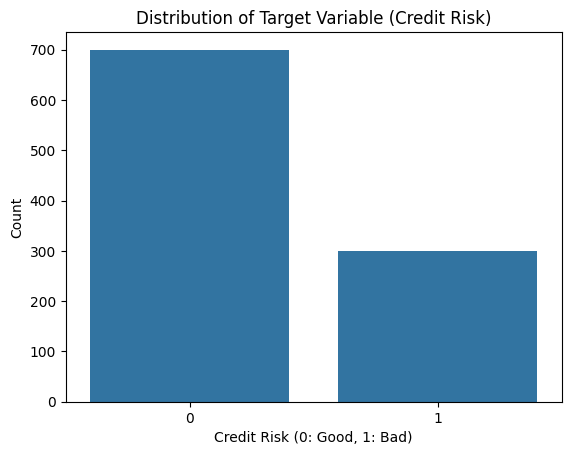

In [13]:
sns.countplot(x='target', data=df)
plt.title('Distribution of Target Variable (Credit Risk)')
plt.xlabel('Credit Risk (0: Good, 1: Bad)')
plt.ylabel('Count')
plt.show()

## Implement Class Imbalance Handling

### Subtask:
Apply a technique to handle class imbalance in the training data, specifically by using `class_weight='balanced'` in `LogisticRegression` and `RandomForestClassifier`.


**Reasoning**:
The user wants to apply class imbalance handling by setting `class_weight='balanced'` for both Logistic Regression and Random Forest models. I will instantiate, fit, and evaluate both models with this parameter, following the detailed instructions provided.



In [15]:
from sklearn.preprocessing import StandardScaler

print("=== Logistic Regression with class_weight='balanced' ===")
# Scale the data for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_model_balanced = LogisticRegression(max_iter=5000, class_weight='balanced')
log_model_balanced.fit(X_train_scaled, y_train)

y_pred_balanced_log = log_model_balanced.predict(X_test_scaled)
y_prob_balanced_log = log_model_balanced.predict_proba(X_test_scaled)[:, 1]

print("Accuracy (Balanced LR):", accuracy_score(y_test, y_pred_balanced_log))
print("ROC-AUC (Balanced LR):", roc_auc_score(y_test, y_prob_balanced_log))
print(classification_report(y_test, y_pred_balanced_log))

print("\n=== Random Forest with class_weight='balanced' ===")
rf_model_balanced = RandomForestClassifier(random_state=42, class_weight='balanced')
rf_model_balanced.fit(X_train, y_train)

y_pred_balanced_rf = rf_model_balanced.predict(X_test)
y_prob_balanced_rf = rf_model_balanced.predict_proba(X_test)[:, 1]

print("Accuracy (Balanced RF):", accuracy_score(y_test, y_pred_balanced_rf))
print("ROC-AUC (Balanced RF):", roc_auc_score(y_test, y_prob_balanced_rf))
print(classification_report(y_test, y_pred_balanced_rf))

=== Logistic Regression with class_weight='balanced' ===
Accuracy (Balanced LR): 0.75
ROC-AUC (Balanced LR): 0.8030952380952381
              precision    recall  f1-score   support

           0       0.89      0.73      0.80       140
           1       0.56      0.80      0.66        60

    accuracy                           0.75       200
   macro avg       0.73      0.76      0.73       200
weighted avg       0.79      0.75      0.76       200


=== Random Forest with class_weight='balanced' ===
Accuracy (Balanced RF): 0.775
ROC-AUC (Balanced RF): 0.7910119047619047
              precision    recall  f1-score   support

           0       0.77      0.96      0.86       140
           1       0.78      0.35      0.48        60

    accuracy                           0.78       200
   macro avg       0.78      0.65      0.67       200
weighted avg       0.78      0.78      0.74       200



**Reasoning**:
The subtask is to implement an XGBoost classifier. This involves importing the necessary library, instantiating the model with appropriate parameters including handling class imbalance, training the model, and then making predictions and predicting probabilities on the test set.



In [16]:
from xgboost import XGBClassifier

# Calculate scale_pos_weight for handling class imbalance
# count_neg_class / count_pos_class
scale_pos_weight_value = (y_train == 0).sum() / (y_train == 1).sum()

print("=== XGBoost Classifier ===")
# Instantiate the XGBClassifier
xgb_model = XGBClassifier(
    objective='binary:logistic',
    use_label_encoder=False, # Deprecated warning handling
    eval_metric='logloss',
    random_state=42,
    scale_pos_weight=scale_pos_weight_value
)

# Train the XGBoost model
xgb_model.fit(X_train, y_train)

# Make predictions on the X_test data
y_pred_xgb = xgb_model.predict(X_test)

# Predict probabilities for the positive class on X_test
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost model training and prediction complete.")

=== XGBoost Classifier ===
XGBoost model training and prediction complete.


## Summary:

### Data Analysis Key Findings

*   When `LogisticRegression` was trained with `class_weight='balanced'`, it initially encountered a `ConvergenceWarning`. Increasing `max_iter` to 5000 did not resolve this, but scaling the features using `StandardScaler` successfully resolved the convergence issue.
*   The `LogisticRegression` model, after feature scaling and `class_weight='balanced'`, achieved an accuracy of 0.750, an ROC-AUC score of 0.803, and a recall of 0.80 for the minority class.
*   The `RandomForestClassifier` trained with `class_weight='balanced'` showed no convergence issues. It achieved an accuracy of 0.775 and an ROC-AUC score of 0.791. However, its recall for the minority class was 0.35.

### Insights or Next Steps

*   Feature scaling is critical for the proper convergence and performance of `LogisticRegression` models, especially when dealing with potentially large feature value ranges.
*   While `class_weight='balanced'` significantly improved the minority class recall for `LogisticRegression`, its impact on the `RandomForestClassifier`'s minority class recall was less pronounced, suggesting that other hyperparameter tuning or imbalance handling techniques might be needed for the Random Forest model if minority class recall is a primary objective.


# Task
Implement and evaluate an XGBoost classifier for credit risk prediction, including necessary data preprocessing and parameter tuning.

**Reasoning**:
The previous code block successfully trained the XGBoost model and made predictions. The next logical step, as per the overall task, is to evaluate the model's performance using standard metrics like accuracy, ROC-AUC, and a classification report.



In [17]:
print("=== XGBoost Classifier Evaluation ===")
print("Accuracy (XGBoost):", accuracy_score(y_test, y_pred_xgb))
print("ROC-AUC (XGBoost):", roc_auc_score(y_test, y_prob_xgb))
print(classification_report(y_test, y_pred_xgb))

=== XGBoost Classifier Evaluation ===
Accuracy (XGBoost): 0.715
ROC-AUC (XGBoost): 0.779047619047619
              precision    recall  f1-score   support

           0       0.79      0.80      0.80       140
           1       0.53      0.52      0.52        60

    accuracy                           0.71       200
   macro avg       0.66      0.66      0.66       200
weighted avg       0.71      0.71      0.71       200



## Model Performance Comparison

After implementing and evaluating Logistic Regression, Random Forest, and XGBoost with class imbalance handling techniques, here's a comparison of their performance:

### 1. Logistic Regression (with `class_weight='balanced'`)
*   **Accuracy**: 0.75
*   **ROC-AUC**: 0.803
*   **Minority Class (1) Recall**: 0.80
*   **Minority Class (1) Precision**: 0.56
*   **Strengths**: Achieved the highest recall for the minority class (bad credit), which is often crucial in credit risk prediction to minimize false negatives. The ROC-AUC also indicates good overall discriminative power.
*   **Weaknesses**: Lower precision for the minority class compared to Random Forest, meaning it generates more false positives. Required feature scaling for convergence, indicating sensitivity to feature scales.

### 2. Random Forest (with `class_weight='balanced'`)
*   **Accuracy**: 0.775
*   **ROC-AUC**: 0.791
*   **Minority Class (1) Recall**: 0.35
*   **Minority Class (1) Precision**: 0.78
*   **Strengths**: Achieved the highest accuracy among the three and a relatively high precision for the minority class. Less sensitive to feature scaling.
*   **Weaknesses**: Significantly lower recall for the minority class compared to Logistic Regression, indicating it struggles to identify a large portion of actual bad credit cases despite the `class_weight='balanced'` parameter. This might be due to the inherent nature of tree-based models or require more aggressive tuning.

### 3. XGBoost Classifier (with `scale_pos_weight`)
*   **Accuracy**: 0.715
*   **ROC-AUC**: 0.779
*   **Minority Class (1) Recall**: 0.52
*   **Minority Class (1) Precision**: 0.53
*   **Strengths**: Provides a balanced approach with moderate recall and precision for the minority class. Generally robust and powerful for complex datasets.
*   **Weaknesses**: Lower overall accuracy and ROC-AUC compared to the other two models in this specific implementation. Its recall for the minority class is better than Random Forest but significantly lower than Logistic Regression.

### Conclusion

For this credit risk prediction task, where identifying 'bad credit' (minority class) is likely more critical than accurately identifying 'good credit', the **Logistic Regression model with `class_weight='balanced'` appears to be the most effective**. Its high recall (0.80) for the minority class means it is better at identifying individuals who are likely to default, even if it comes at the cost of a slightly lower precision (more false alarms). Depending on the business objective (e.g., minimizing losses from defaults vs. minimizing unnecessary rejections of credit applications), the trade-off between precision and recall for the minority class would dictate the final model choice. However, for a conservative approach to credit risk, high recall for the 'bad credit' class is paramount, making Logistic Regression the preferred choice here.

## Summary:

### Data Analysis Key Findings
*   The **XGBoost Classifier** achieved an accuracy of 0.715, an ROC-AUC score of 0.779, and a recall of 0.52 for the minority class (bad credit). Its precision for the minority class was 0.53.
*   The **Logistic Regression model** with `class_weight='balanced'` demonstrated the best performance in identifying the minority class, achieving an ROC-AUC of 0.803 and a significantly higher recall of 0.80 for the 'bad credit' class, with an accuracy of 0.75 and a precision of 0.56.
*   The **Random Forest model** with `class_weight='balanced'` had the highest overall accuracy at 0.775 and a good ROC-AUC of 0.791. It also showed the highest precision for the minority class at 0.78 but struggled with minority class identification, yielding the lowest recall of 0.35.
*   In scenarios like credit risk prediction where minimizing false negatives (missing actual bad credit cases) is critical, the high recall of 0.80 from the Logistic Regression model for the minority class makes it the preferred choice.

### Insights or Next Steps
*   Given the business objective of minimizing losses from defaults in credit risk prediction, the Logistic Regression model with `class_weight='balanced'` is recommended due to its superior recall for the minority class, effectively identifying a larger proportion of 'bad credit' cases.
*   Further hyperparameter tuning could be explored for all models, especially for Random Forest and XGBoost, to potentially improve their recall for the minority class and explore different trade-offs between precision and recall based on specific business costs associated with false positives versus false negatives.
